### Figure4 US and World Plots

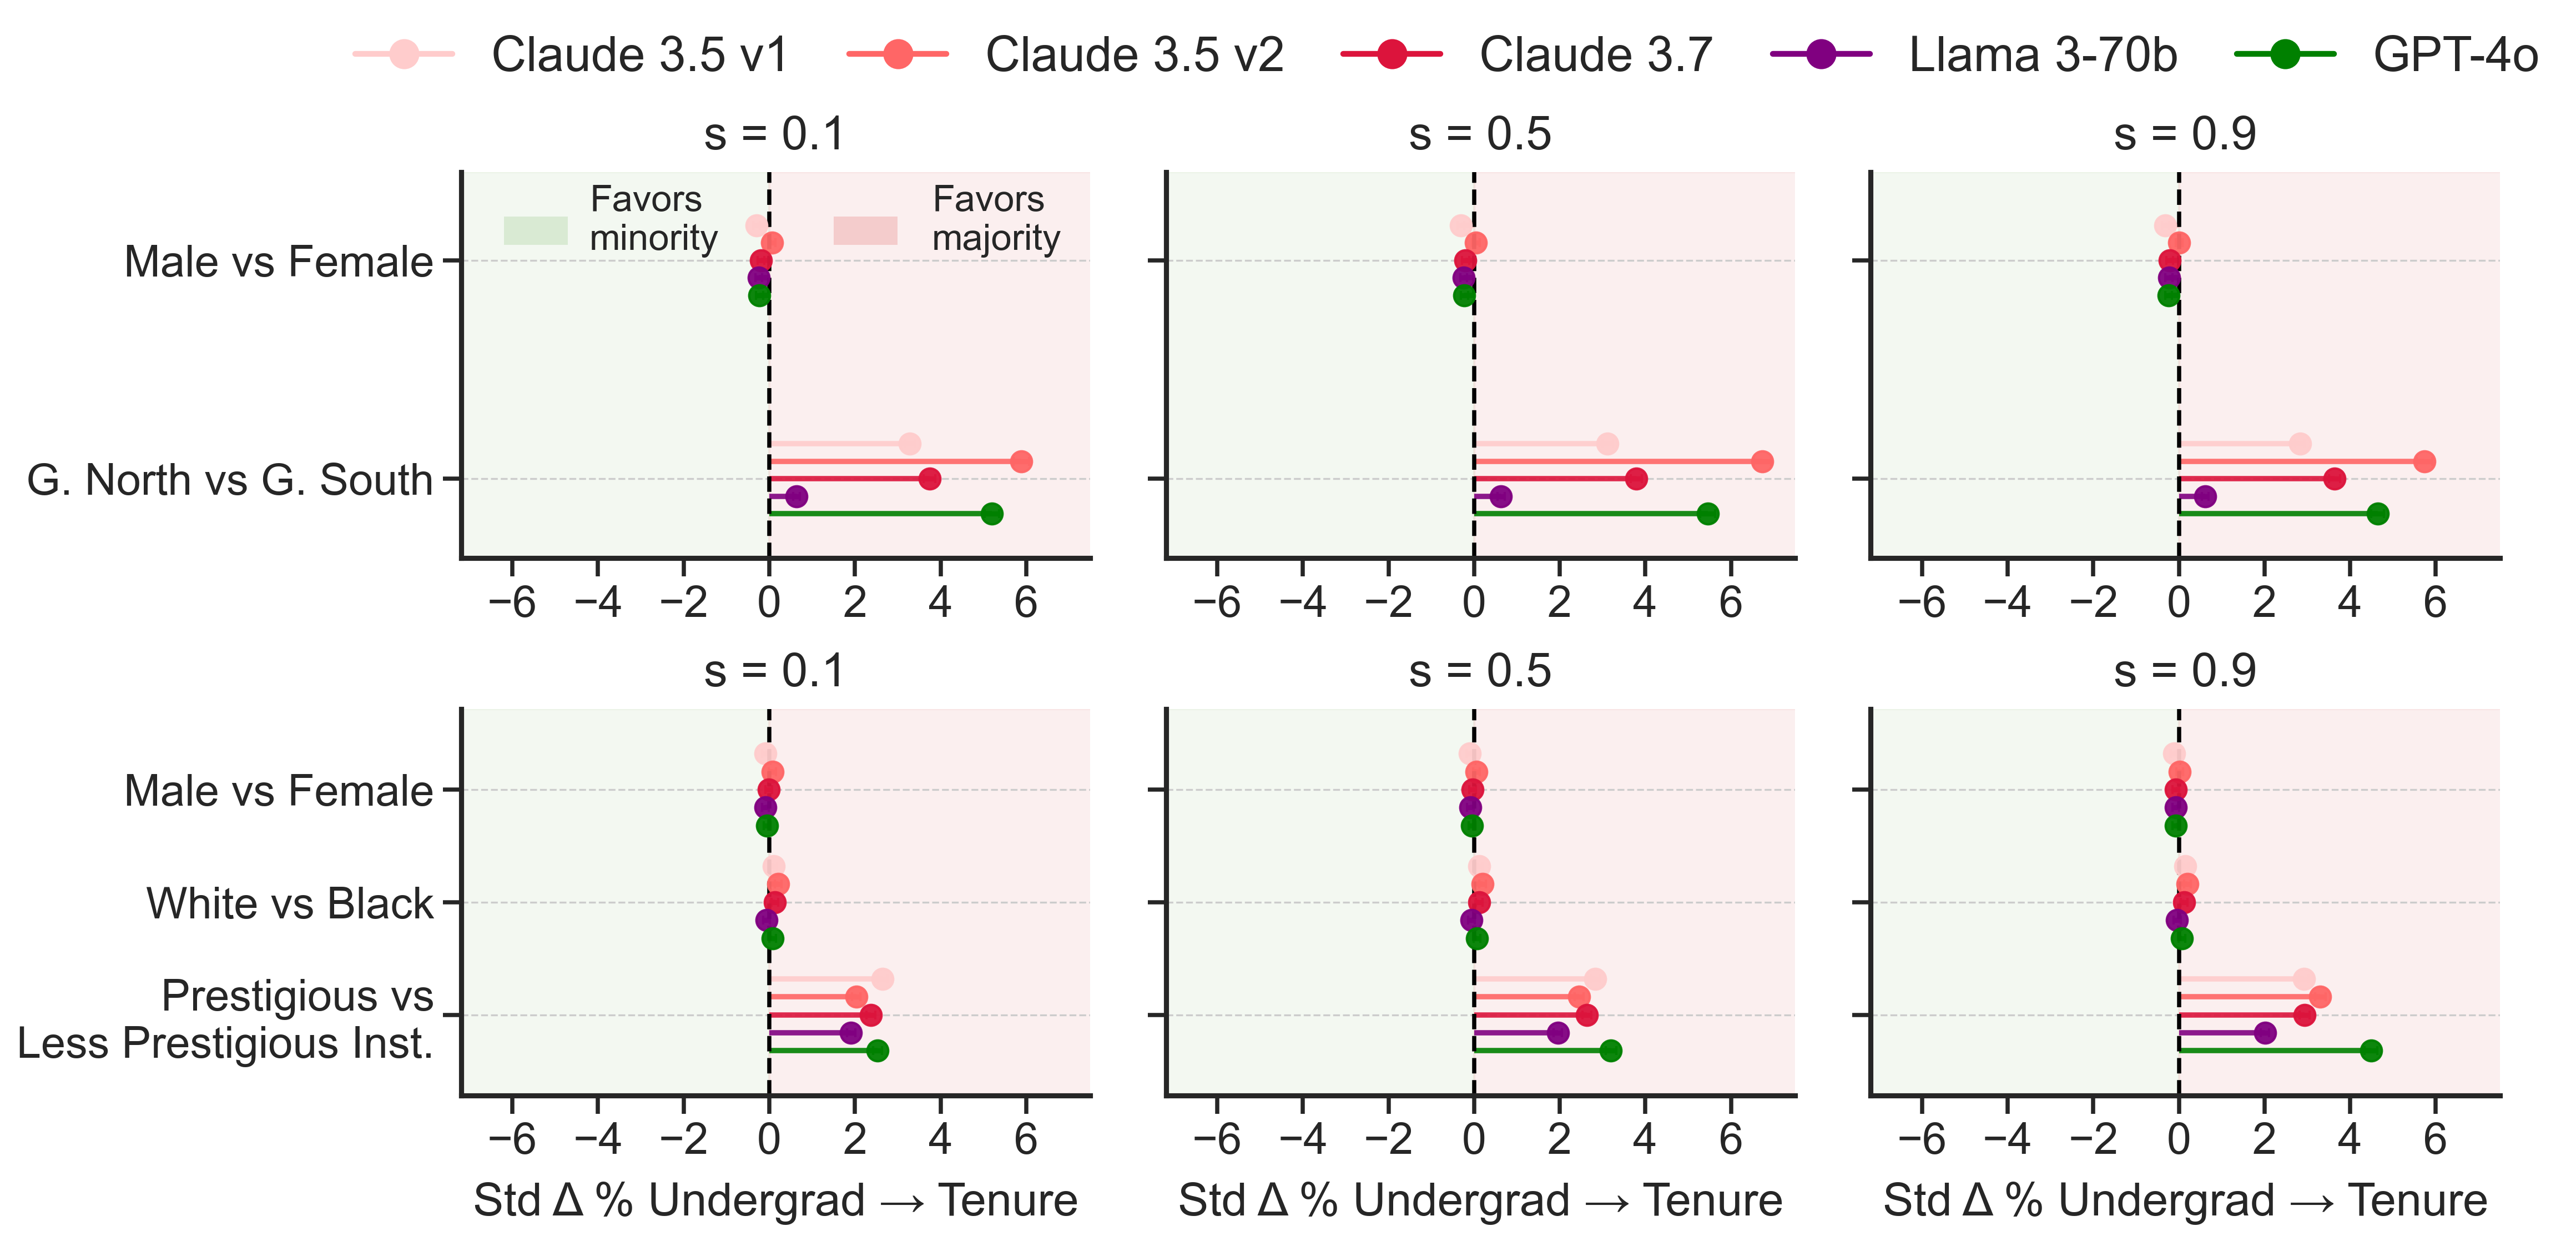

In [2]:
# ============================================================
# FIGURE 4 — Std Δ Qualification (Mean Diff) — World & US
# Reduced-size NHB-style formatting
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ----------------------------
# 1. GLOBAL STYLE SETTINGS (NHB SCALED)
# ----------------------------
plt.style.use("seaborn-v0_8-white")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20.5,
    "legend.fontsize": 21,
    "axes.linewidth": 2.2,
    "xtick.labelsize": 19,
    "ytick.labelsize": 19,
    "figure.figsize": (14.8, 8.2),     # << NEW NATURAL NHB SIZE
    "figure.dpi": 300,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

# ----------------------------
# 2. LOAD AND PREPARE DATA
# ----------------------------
world_df = pd.read_csv("figure4_results_world.csv")
us_df = pd.read_csv("figure4_results_US.csv")

world_df["Factor"] = world_df["Factor"].replace({
    "Gender": "Male vs Female",
    "Location": "G. North vs G. South"
})

us_df["Factor"] = us_df["Factor"].replace({
    "Gender": "Male vs Female",
    "Race": "White vs Black",
    "Institution": "Prestigious vs\nLess Prestigious Inst."
})

world_df["Factor"] = pd.Categorical(world_df["Factor"],
                                    categories=["Male vs Female", "G. North vs G. South"],
                                    ordered=True)

us_df["Factor"] = pd.Categorical(us_df["Factor"],
                                 categories=["Male vs Female", "White vs Black", "Prestigious vs\nLess Prestigious Inst."],
                                 ordered=True)

world_df.rename(columns={"s_value": "s"}, inplace=True)
us_df.rename(columns={"s_value": "s"}, inplace=True)

model_names = ['Claude 3.5 v1', 'Claude 3.5 v2', 'Claude 3.7', 'LLaMA 3-70b', 'GPT-4o']
model_colors = ['#FFCCCC', '#FF6666', 'crimson', 'purple', 'green']
s_values = [0.1, 0.5, 0.9]

# ----------------------------
# 3. PLOTTING FUNCTION (scaled)
# ----------------------------
def plot_panel(ax, data, s_value, show_ylabel, show_xlabel, is_us=False):

    subset = data[data["s"] == s_value]
    y_labels = subset["Factor"].cat.categories
    y_pos = np.arange(len(y_labels))
    # Use slightly larger offsets for the US case
    offsets = np.linspace(-0.32, 0.32, len(model_names)) if is_us else np.linspace(-0.16, 0.16, len(model_names))

    

    # background shading
    ax.axvspan(-10, 0, color="#D9EAD3", alpha=0.3, zorder=0)
    ax.axvspan(0, 10, color="#F4CCCC", alpha=0.3, zorder=0)

    for model, color, offset in zip(model_names, model_colors, offsets):
        md = subset[subset["Model"] == model].set_index("Factor").reindex(y_labels)
        means = md["Mean_Diff"].values
        errs = md["Std_Error"].values

        for y, m in zip(y_pos, means):
            xa, xb = (0, m) if m >= 0 else (m, 0)
            ax.hlines(y + offset, xa, xb, color=color, lw=2.3, alpha=0.9)

        ax.errorbar(means, y_pos + offset,
                    xerr=errs, fmt="o",
                    color=color, ms=9, lw=2.2, capsize=2, alpha=0.95)

    ax.axvline(0, color="black", lw=1.8, ls="--")
    ax.set_title(f"s = {s_value}", pad=10)

    if show_ylabel:
        ax.set_yticks(y_pos)
        ax.set_yticklabels(y_labels)
        ax.invert_yaxis()
    else:
        ax.tick_params(axis="y", labelleft=False)

    if show_xlabel:
        ax.set_xlabel("Std Δ % Undergrad → Tenure", labelpad=8)

    ax.set_xlim(-7.2, 7.5)
    ax.set_xticks([-6, -4, -2, 0, 2, 4, 6])
    ax.tick_params(axis="both", width=1.8, length=8)
    #ax.grid(axis="y", linestyle="--", alpha=0.65)
    # Grid above shading, matching WEAT-style layering
    ax.grid(axis="y", linestyle="--", alpha=0.99, zorder=5)

    ax.margins(y=0.15)

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)


# ----------------------------
# 4. BUILD FIGURE (reduced size)
# ----------------------------
fig, axs = plt.subplots(
    2, 3,
    figsize=(15.8, 7.2),     # << FINAL FIGURE SIZE
    sharey="row",
    constrained_layout=False,
    gridspec_kw={"wspace": 0.12, "hspace": 0.39}
)
# Force all backgrounds to pure white so shading looks identical to WEAT figure
fig.patch.set_facecolor("white")
for ax_row in axs:
    for ax in ax_row:
        ax.set_facecolor("white")


for i, s_val in enumerate(s_values):
    # World panels (top row) — normal offsets
    plot_panel(axs[0, i], world_df, s_val, show_ylabel=(i==0), show_xlabel=False, is_us=False)

    # US panels (bottom row) — wider model offsets
    plot_panel(axs[1, i], us_df, s_val, show_ylabel=(i==0), show_xlabel=True, is_us=True)


# Background shading legend
bias_patches = [
    Patch(facecolor="#D9EAD3", alpha=0.5, edgecolor="none", label="Favors minority"),
    Patch(facecolor="#F4CCCC", alpha=0.5, edgecolor="none", label="Favors majority"),
]

# -------------------------------------------
# ADD NHB-STYLE BACKGROUND LEGEND (TOP-LEFT PANEL)
# -------------------------------------------
first_ax = axs[0, 0]  # top-left panel
# Favors minority (negative / green side)
first_ax.add_patch(
    plt.Rectangle(
        xy=(-6.2, -0.2),   # ⬆ raised higher (was 1.8)
        width=1.5,
        height=0.13,
        facecolor="#D9EAD3",
        edgecolor="none",
        alpha=1.0,
        zorder=10
    )
)
first_ax.text(
    -4.2, -0.18, "Favors\nminority",   # ⬆ raised higher (was 2.1)
    fontsize=16,
    ha="left",
    va="center",
    zorder=11
)

# Favors majority (positive / pink side)
first_ax.add_patch(
    plt.Rectangle(
        xy=(1.5, -0.2),   # ⬆ raised higher
        width=1.5,
        height=0.13,
        facecolor="#F4CCCC",
        edgecolor="none",
        alpha=1.0,
        zorder=10
    )
)
first_ax.text(
    3.8, -0.18, "Favors\nmajority",   # ⬆ raised higher
    fontsize=16,
    ha="left",
    va="center",
    zorder=11
)



# # --- Custom handles (real lines, no errorbar containers) ---
# legend_handles = [
#     Line2D(
#         [0, 0.6], [0, 0],      # <--- controls legend line length
#         color=color,
#         marker='o',
#         markersize=12,
#         linewidth=2.5,
#         label=model,
#         alpha=1.0
#     )
#     for model, color in zip(model_names, model_colors)
# ]

# # --- Build legend ---
# fig.legend(
#     handles=legend_handles,
#     labels=model_names,
#     loc="upper center",
#     bbox_to_anchor=(0.5, 1.03),
#     ncol=len(model_names),
#     frameon=False,
#     handletextpad=0.8,
#     columnspacing=1.2
# )

# --- Custom handles (real lines, no errorbar containers) ---
legend_handles = [
    Line2D(
        [0, 0.6], [0, 0],
        color=color,
        marker='o',
        markersize=12,
        linewidth=2.5,
        label=model,
        alpha=1.0
    )
    for model, color in zip(model_names, model_colors)
]

# --- Create display labels (LLaMA → Llama) ---
legend_labels = [name.replace("LLaMA", "Llama") for name in model_names]

# --- Build legend ---
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=len(legend_labels),
    frameon=False,
    handletextpad=0.8,
    columnspacing=1.2
)


plt.subplots_adjust(hspace=0.7, wspace=0.15, top=0.88)

fig.savefig("figure4.png", dpi=300, bbox_inches="tight")
plt.show()
